# Практическая работа №1. Самостоятельный анализ Bike Sharing

**Цель:** исследовать связь дневного числа прокатов с погодой и типом дня, а также изменение спроса во времени.

**Данные:** `day.csv`, дневные наблюдения Capital Bikeshare за 2011–2012 годы, Вашингтон, США.

**Источник:** Fanaee-T, H. (2013). [Bike Sharing — UCI Machine Learning Repository](https://doi.org/10.24432/C5W894). Лицензия: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

## 1. Окружение и загрузка

In [ ]:
from pathlib import Path
import csv
import hashlib
import io
import json
import platform
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib
import pyarrow
from IPython.display import display, Markdown

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "bike_sharing" / "day.csv"
assert DATA_PATH.exists(), "Сначала выполните scripts/download_data.py из папки практики."
OUT = ROOT / "output" / "bike_sharing"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 25)
pd.set_option("display.precision", 3)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 110})
display(pd.Series({"Python": platform.python_version(), "pandas": pd.__version__,
                   "numpy": np.__version__, "matplotlib": matplotlib.__version__,
                   "pyarrow": pyarrow.__version__}, name="Версия").to_frame())
source = json.loads((DATA_PATH.parent / "source.json").read_text(encoding="utf-8"))
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source["day_csv_sha256"]
text = DATA_PATH.read_text(encoding="utf-8-sig")
delimiter = csv.Sniffer().sniff(text[:8192], delimiters=",;\t").delimiter
assert delimiter == ","
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig", sep=delimiter)
print("Разделитель:", repr(delimiter), "; UTF-8 читается без ошибок; размер:", df.shape)
display(df.head())
assert df.shape == (731, 16)
display(Markdown("**Вывод.** Загружена таблица: 731 строка, "
                 "16 исходных полей, несколько числовых показателей и категориальные коды. "
                 "Столбец `dteday` содержит дату наблюдения."))

: 

## 2. Паспорт данных и диагностика

В описаниях UCI и архивного Readme различаются названия сезонов и нормировка температуры. Поэтому `season` используется как код, а `temp` и `atemp` — в нормированной шкале. Влажность переводится в проценты: `hum * 100`.

In [ ]:
dictionary = {
    "instant": "Индекс записи; не измеряемый признак",
    "dteday": "Дата дня наблюдения, YYYY-MM-DD",
    "season": "Категория сезона 1-4; названия расходятся в метаданных",
    "yr": "Код года: 0 = 2011, 1 = 2012",
    "mnth": "Месяц: 1-12",
    "holiday": "Праздничный день: 1 = да, 0 = нет",
    "weekday": "День недели: 0 = воскресенье, ..., 6 = суббота; проверяется по дате",
    "workingday": "Рабочий день: не выходной и не праздник",
    "weathersit": "Погода: 1 = ясно/мало облаков, 2 = туман/облачность, 3 = небольшие осадки, 4 = сильные осадки",
    "temp": "Нормированная температура, без обратного перевода в °C",
    "atemp": "Нормированная ощущаемая температура",
    "hum": "Нормированная относительная влажность: исходное значение / 100",
    "windspeed": "Нормированная скорость ветра",
    "casual": "Число прокатов незарегистрированными пользователями за день",
    "registered": "Число прокатов зарегистрированными пользователями за день",
    "cnt": "Общее число прокатов за день: casual + registered",
}
display(pd.DataFrame({"Смысл": dictionary, "Исходный dtype": df.dtypes.astype(str)}))
buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())
display(df.describe(include="all").T)
display(Markdown("**Вывод.** Pandas распознал дату строкой, а категориальные коды - целыми числами. "
                 "Категориальные коды исключаются из числового анализа."))

,Смысл,Исходный dtype
instant,Индекс записи; не измеряемый признак,int64
dteday,"Дата дня наблюдения, YYYY-MM-DD",object
season,Категория сезона 1-4; названия расходятся в ме...,int64
yr,"Код года: 0 = 2011, 1 = 2012",int64
mnth,Месяц: 1-12,int64
holiday,"Праздничный день: 1 = да, 0 = нет",int64
weekday,"День недели: 0 = воскресенье, ..., 6 = суббота...",int64
workingday,Рабочий день: не выходной и не праздник,int64
weathersit,"Погода: 1 = ясно/мало облаков, 2 = туман/облач...",int64
temp,"Нормированная температура, без обратного перев...",float64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 133.6 KB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,731.0,NaN,NaN,NaN,366.0,211.166,1.0,183.5,366.0,548.5,731.0
dteday,731,731,2011-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,731.0,NaN,NaN,NaN,2.497,1.111,1.0,2.0,3.0,3.0,4.0
yr,731.0,NaN,NaN,NaN,0.501,0.5,0.0,0.0,1.0,1.0,1.0
mnth,731.0,NaN,NaN,NaN,6.52,3.452,1.0,4.0,7.0,10.0,12.0
holiday,731.0,NaN,NaN,NaN,0.029,0.167,0.0,0.0,0.0,0.0,1.0
weekday,731.0,NaN,NaN,NaN,2.997,2.005,0.0,1.0,3.0,5.0,6.0
workingday,731.0,NaN,NaN,NaN,0.684,0.465,0.0,0.0,1.0,1.0,1.0
weathersit,731.0,NaN,NaN,NaN,1.395,0.545,1.0,1.0,1.0,2.0,3.0
temp,731.0,NaN,NaN,NaN,0.495,0.183,0.059,0.337,0.498,0.655,0.862


**Вывод.** Pandas распознал дату строкой, а категориальные коды - целыми числами. Категориальные коды исключаются из числового анализа.

## 3. Качество и предобработка

In [ ]:
quality = pd.DataFrame({"Пропуски": df.isna().sum(), "Уникальных": df.nunique()})
display(quality)
duplicates = int(df.duplicated().sum())
print("Полных дубликатов:", duplicates)
dates = pd.to_datetime(df.dteday, format="%Y-%m-%d", errors="raise")
checks = pd.Series({
    "Повторные даты": int(dates.duplicated().sum()),
    "Повторные идентификаторы": int(df.instant.duplicated().sum()),
    "Нарушения cnt = casual + registered": int(df.cnt.ne(df.casual + df.registered).sum()),
    "Отрицательные счётчики": int((df[["casual", "registered", "cnt"]] < 0).any(axis=1).sum()),
    "Нормированные значения вне [0; 1]": int((~df[["temp", "atemp", "hum", "windspeed"]].apply(lambda s: s.between(0, 1))).any(axis=1).sum()),
    "Бесконечные числа": int(np.isinf(df.select_dtypes("number")).sum().sum()),
    "Год не совпадает с датой": int((df.yr + 2011).ne(dates.dt.year).sum()),
    "Месяц не совпадает с датой": int(df.mnth.ne(dates.dt.month).sum()),
    "День недели не совпадает с датой": int(df.weekday.ne((dates.dt.dayofweek + 1) % 7).sum()),
    "Признак рабочего дня противоречив": int(df.workingday.ne((~df.weekday.isin([0, 6]) & df.holiday.eq(0)).astype(int)).sum()),
}, name="Нарушений")
display(checks.to_frame())
missing_days = pd.date_range(dates.min(), dates.max()).difference(pd.DatetimeIndex(dates))
print("Пропущенных календарных дней:", len(missing_days))
assert quality["Пропуски"].sum() == 0 and duplicates == 0 and checks.sum() == 0 and len(missing_days) == 0
for col, allowed in {"season": [1, 2, 3, 4], "weathersit": [1, 2, 3, 4],
                     "yr": [0, 1], "holiday": [0, 1], "workingday": [0, 1]}.items():
    assert df[col].isin(allowed).all()
zero_humidity = df.loc[df.hum.eq(0), ["dteday", "hum", "cnt"]]
display(zero_humidity)
display(Markdown(f"**Вывод.** Пропусков и полных дублей нет; даты уникальны и календарный ряд непрерывен. "
                 f"Обнаружено {len(zero_humidity)} дней с нулевой суточной влажностью. "
                 "Нулевая влажность отмечена отдельным признаком; строки сохранены."))

,Пропуски,Уникальных
instant,0,731
dteday,0,731
season,0,4
yr,0,2
mnth,0,12
holiday,0,2
weekday,0,7
workingday,0,2
weathersit,0,3
temp,0,499


Полных дубликатов: 0


,Нарушений
Повторные даты,0
Повторные идентификаторы,0
Нарушения cnt = casual + registered,0
Отрицательные счётчики,0
Нормированные значения вне [0; 1],0
Бесконечные числа,0
Год не совпадает с датой,0
Месяц не совпадает с датой,0
День недели не совпадает с датой,0
Признак рабочего дня противоречив,0


Пропущенных календарных дней: 0


,dteday,hum,cnt
68,2011-03-10,0.0,623


**Вывод.** Пропусков и полных дублей нет; даты уникальны и календарный ряд непрерывен. Обнаружено 1 дней с нулевой суточной влажностью. Нулевая влажность отмечена отдельным признаком; строки сохранены.

## 4. Типы и память
Сравниваются одинаковые 16 исходных столбцов, до добавления новых признаков.
Счётчики переводятся в минимальный подходящий беззнаковый целый тип.

In [ ]:
before = int(df.memory_usage(deep=True).sum())
clean_df = df.copy()
clean_df["dteday"] = dates
categorical = ["season", "yr", "mnth", "weekday", "weathersit"]
for col in categorical:
    clean_df[col] = clean_df[col].astype("category")
for col in ["holiday", "workingday"]:
    clean_df[col] = clean_df[col].astype(bool)
for col in ["instant", "casual", "registered", "cnt"]:
    clean_df[col] = pd.to_numeric(clean_df[col], downcast="unsigned")
after = int(clean_df.memory_usage(deep=True).sum())
memory_reduction = (1 - after / before) * 100
display(pd.DataFrame({"До": df.dtypes.astype(str), "После": clean_df.dtypes.astype(str)}))
display(pd.DataFrame({"Этап": ["До", "После"], "Байт": [before, after],
                      "KiB": [before / 1024, after / 1024]}))
reversed_df = clean_df.copy()
reversed_df["dteday"] = reversed_df.dteday.dt.strftime("%Y-%m-%d")
pd.testing.assert_frame_equal(df, reversed_df.astype(df.dtypes))
display(Markdown(f"**Вывод.** Память снижена на {memory_reduction:.1f}%. Дата стала `datetime`, "
                 "коды - категориями, бинарные поля - логическими. Проверено обратное восстановление "
                 "всех исходных значений. Вещественные измерения оставлены `float64`, чтобы не снижать точность."))

,До,После
instant,int64,uint16
dteday,object,datetime64[ns]
season,int64,category
yr,int64,category
mnth,int64,category
holiday,int64,bool
weekday,int64,category
workingday,int64,bool
weathersit,int64,category
temp,float64,float64


,Этап,Байт,KiB
0,До,136829,133.622
1,После,41549,40.575


**Вывод.** Память снижена на 69.6%. Дата стала `datetime`, коды - категориями, бинарные поля - логическими. Проверено обратное восстановление всех исходных значений. Вещественные измерения оставлены `float64`, чтобы не снижать точность.

## 5. Вычисляемые признаки
`humidity_pct = hum * 100`; `casual_share_pct = casual / cnt * 100`;
`humidity_zero_flag = (hum == 0)`. Доля определяется только для дней с `cnt > 0`.

In [ ]:
assert clean_df.cnt.gt(0).all()
clean_df["humidity_pct"] = clean_df.hum * 100
clean_df["casual_share_pct"] = clean_df.casual / clean_df.cnt * 100
clean_df["humidity_zero_flag"] = clean_df.hum.eq(0)
display(clean_df[["dteday", "hum", "humidity_pct", "casual", "cnt", "casual_share_pct", "humidity_zero_flag"]].head())
display(Markdown("**Вывод.** Влажность представлена в процентах согласно нормировке источника. "
                 "Доля незарегистрированных пользователей характеризует состав дневного спроса; "
                 "индикатор нулевой влажности сохраняет информацию о потенциально сомнительном измерении."))

,dteday,hum,humidity_pct,casual,cnt,casual_share_pct,humidity_zero_flag
0,2011-01-01,0.806,80.583,331,985,33.604,False
1,2011-01-02,0.696,69.609,131,801,16.355,False
2,2011-01-03,0.437,43.727,120,1349,8.895,False
3,2011-01-04,0.590,59.044,108,1562,6.914,False
4,2011-01-05,0.437,43.696,82,1600,5.125,False


**Вывод.** Влажность представлена в процентах согласно нормировке источника. Доля незарегистрированных пользователей характеризует состав дневного спроса; индикатор нулевой влажности сохраняет информацию о потенциально сомнительном измерении.

## 6. Составной фильтр
Выбираются рабочие дни с нормированной температурой выше 0.5 и влажностью ниже 65%.

In [ ]:
subset = clean_df.loc[clean_df.workingday & (clean_df.temp > 0.5) & (clean_df.humidity_pct < 65),
                      ["dteday", "temp", "humidity_pct", "cnt"]]
query_subset = clean_df.query("workingday == True and temp > 0.5 and humidity_pct < 65")
assert subset.index.equals(query_subset.index)
display(subset.head())
display(Markdown(f"**Вывод.** Условия выполняются в {len(subset)} днях ({len(subset)/len(df):.2%} наблюдений). "
                 f"Среднее число прокатов в срезе {subset.cnt.mean():.1f}, во всём наборе {clean_df.cnt.mean():.1f}. "))

,dteday,temp,humidity_pct,cnt
48,2011-02-18,0.522,51.667,2927
76,2011-03-18,0.540,52.522,3239
93,2011-04-04,0.573,42.625,3115
107,2011-04-18,0.512,54.250,3429
109,2011-04-20,0.595,61.417,3944


**Вывод.** Условия выполняются в 125 днях (17.10% наблюдений). Среднее число прокатов в срезе 5946.5, во всём наборе 4504.3. 

## 7. Группировки и несколько агрегатных функций
Сравниваем погоду и рабочие/нерабочие дни. Для каждой категории приводим объём группы.
Общая доля casual рассчитывается как отношение сумм, а не среднее дневных процентов.

In [ ]:
weather_stats = clean_df.groupby("weathersit", observed=True).agg(
    days=("cnt", "size"), mean_rentals=("cnt", "mean"), median_rentals=("cnt", "median"),
    std_rentals=("cnt", "std"), total_rentals=("cnt", "sum"),
).sort_index()
day_stats = clean_df.groupby("workingday", observed=True).agg(
    days=("cnt", "size"), mean_rentals=("cnt", "mean"), mean_casual=("casual", "mean"),
    mean_registered=("registered", "mean"), casual_total=("casual", "sum"), total=("cnt", "sum"),
)
day_stats["casual_share_pct"] = day_stats.casual_total / day_stats.total * 100
display(weather_stats.round(2))
display(day_stats.round(2))
best_weather = weather_stats.mean_rentals.idxmax()
display(Markdown(
    f"**Вывод.** Наибольший средний спрос у погодной категории {best_weather}: "
    f"{weather_stats.loc[best_weather, 'mean_rentals']:.1f} прокатов/день. "
    f"Доля casual в суммарных прокатах рабочих дней {day_stats.loc[True, 'casual_share_pct']:.2f}%, "
    f"нерабочих - {day_stats.loc[False, 'casual_share_pct']:.2f}%. Состав спроса различается. "
    "Число дней неодинаково, поэтому средний дневной спрос информативнее одной только суммы по группе."
))

,days,mean_rentals,median_rentals,std_rentals,total_rentals
weathersit,,,,,
1,463,4876.79,4844.0,1879.48,2257952
2,247,4035.86,4040.0,1809.11,996858
3,21,1803.29,1817.0,1240.28,37869


,days,mean_rentals,mean_casual,mean_registered,casual_total,total,casual_share_pct
workingday,,,,,,,
False,231,4330.17,1371.13,2959.03,316732,1000269,31.66
True,500,4584.82,606.57,3978.25,303285,2292410,13.23


**Вывод.** Наибольший средний спрос у погодной категории 1: 4876.8 прокатов/день. Доля casual в суммарных прокатах рабочих дней 13.23%, нерабочих - 31.66%. Состав спроса различается. Число дней неодинаково, поэтому средний дневной спрос информативнее одной только суммы по группе.

## 8. Числовая статистика, корреляции и IQR
Категориальные коды и индекс исключены. `casual` и `registered` не включены
в корреляцию с `cnt`, поскольку сумма этих двух столбцов точно равна цели.

In [ ]:
numeric = ["temp", "atemp", "humidity_pct", "windspeed", "cnt"]
display(clean_df[numeric].describe().T.round(3))
corr = clean_df[numeric].corr()
display(corr.round(3))
outlier_rows = []
for col in ["cnt", "temp", "humidity_pct", "windspeed"]:
    q1, q3 = clean_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    candidates = ~clean_df[col].between(lower, upper)
    outlier_rows.append({"Признак": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                         "Нижняя граница": lower, "Верхняя граница": upper,
                         "Кандидатов": int(candidates.sum()), "Доля, %": candidates.mean() * 100})
outliers = pd.DataFrame(outlier_rows).set_index("Признак")
display(outliers.round(3))
humidity_corr_without_zero = clean_df.loc[~clean_df.humidity_zero_flag, ["humidity_pct", "cnt"]].corr().iloc[0, 1]
display(Markdown(
    f"**Вывод.** Корреляция температуры со спросом r = {corr.loc['temp', 'cnt']:.3f}. "
    f"Для влажности r = {corr.loc['humidity_pct', 'cnt']:.3f}; при исключении нулевой влажности "
    f"только из расчёта этой корреляции r = {humidity_corr_without_zero:.3f}. "
    f"IQR выделяет {int(outliers.loc['cnt', 'Кандидатов'])} дней по спросу и "
    f"{int(outliers.loc['windspeed', 'Кандидатов'])} по ветру. Наблюдения сохранены: "
    "экстремальная погода и спрос могут быть реальными, а глобальный IQR не учитывает сезонность. "
    "Корреляции описательные и не отделяют влияние календаря от погоды."
))

,count,mean,std,min,25%,50%,75%,max
temp,731.0,0.495,0.183,0.059,0.337,0.498,0.655,0.862
atemp,731.0,0.474,0.163,0.079,0.338,0.487,0.609,0.841
humidity_pct,731.0,62.789,14.243,0.000,52.000,62.667,73.021,97.250
windspeed,731.0,0.190,0.077,0.022,0.135,0.181,0.233,0.507
cnt,731.0,4504.349,1937.211,22.000,3152.000,4548.000,5956.000,8714.000


,temp,atemp,humidity_pct,windspeed,cnt
temp,1.000,0.992,0.127,-0.158,0.627
atemp,0.992,1.000,0.140,-0.184,0.631
humidity_pct,0.127,0.140,1.000,-0.248,-0.101
windspeed,-0.158,-0.184,-0.248,1.000,-0.235
cnt,0.627,0.631,-0.101,-0.235,1.000


,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Кандидатов,"Доля, %"
Признак,,,,,,,
cnt,3152.000,5956.000,2804.000,-1054.000,10162.000,0,0.000
temp,0.337,0.655,0.318,-0.140,1.133,0,0.000
humidity_pct,52.000,73.021,21.021,20.469,104.552,2,0.274
windspeed,0.135,0.233,0.098,-0.012,0.381,13,1.778


**Вывод.** Корреляция температуры со спросом r = 0.627. Для влажности r = -0.101; при исключении нулевой влажности только из расчёта этой корреляции r = -0.115. IQR выделяет 0 дней по спросу и 13 по ветру. Наблюдения сохранены: экстремальная погода и спрос могут быть реальными, а глобальный IQR не учитывает сезонность. Корреляции описательные и не отделяют влияние календаря от погоды.

## 9.1. Категориальное сравнение

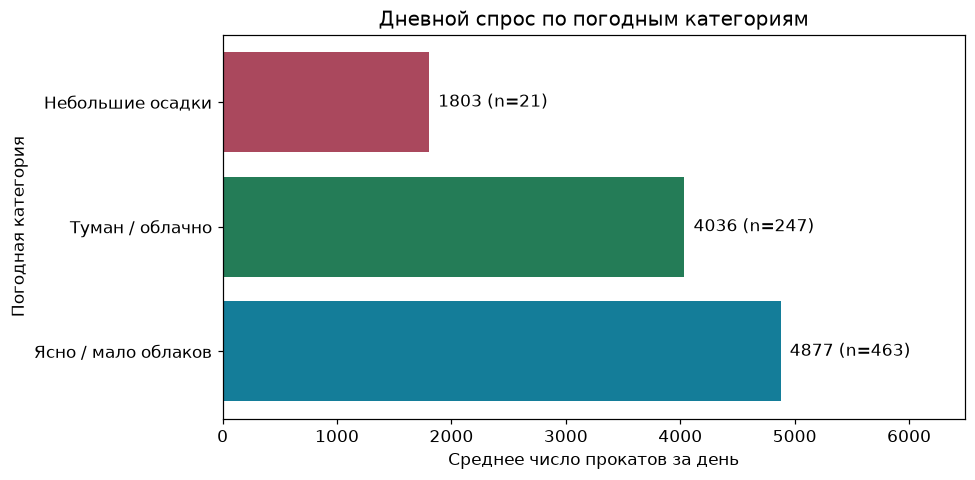

**Вывод.** В дни с небольшими осадками средний спрос ниже, чем в ясные дни. Число наблюдений указано в подписях. Категория 4 в данных отсутствует.

In [ ]:
weather_labels = {1: "Ясно / мало облаков", 2: "Туман / облачно", 3: "Небольшие осадки", 4: "Сильные осадки"}
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh([weather_labels[int(i)] for i in weather_stats.index], weather_stats.mean_rentals,
               color=["#147d99", "#247c57", "#aa485d"][:len(weather_stats)])
ax.bar_label(bars, labels=[f"{mean:.0f} (n={int(n)})" for mean, n in
                         zip(weather_stats.mean_rentals, weather_stats.days)], padding=6)
ax.set_xlim(0, weather_stats.mean_rentals.max() * 1.33)
ax.set(xlabel="Среднее число прокатов за день", ylabel="Погодная категория",
       title="Дневной спрос по погодным категориям")
plt.tight_layout()
plt.savefig(FIG / "01_weather.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** В дни с небольшими осадками средний спрос ниже, чем в ясные дни. "
                 "Число наблюдений указано в подписях. Категория 4 в данных отсутствует."))

## 9.2. Распределение спроса

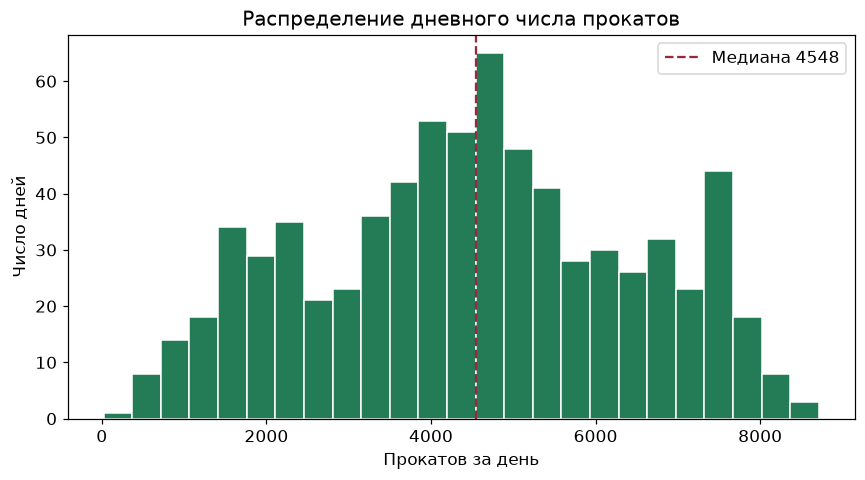

**Вывод.** Дневной спрос меняется от 22 до 8714 прокатов, медиана 4548. Распределение объединяет два года и разные сезоны.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(clean_df.cnt, bins=25, color="#247c57", edgecolor="white")
ax.axvline(clean_df.cnt.median(), color="#99283f", linestyle="--", label=f"Медиана {clean_df.cnt.median():.0f}")
ax.set(xlabel="Прокатов за день", ylabel="Число дней", title="Распределение дневного числа прокатов")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "02_demand.png", dpi=150)
plt.show()
display(Markdown(f"**Вывод.** Дневной спрос меняется от {clean_df.cnt.min()} до {clean_df.cnt.max()} "
                 f"прокатов, медиана {clean_df.cnt.median():.0f}. Распределение объединяет два года "
                 "и разные сезоны."))

## 9.3. Взаимосвязь температуры и спроса

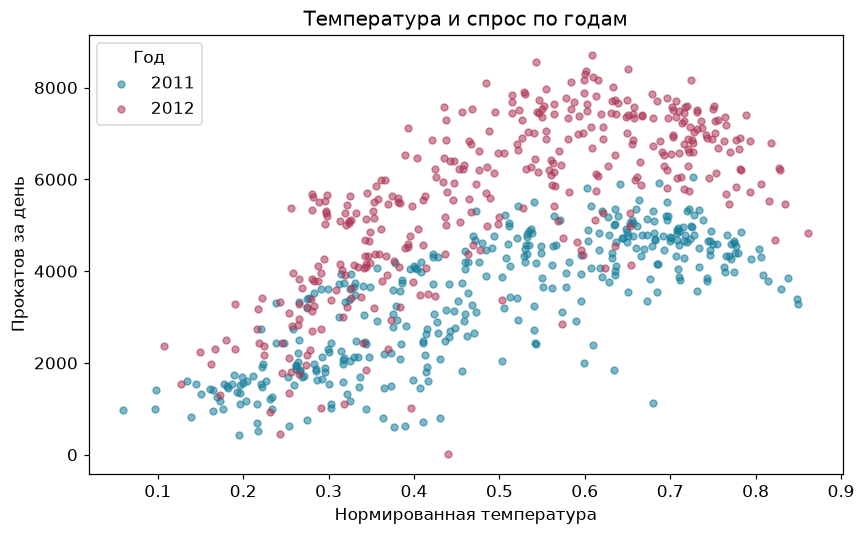

**Вывод.** Видна положительная связь температуры со спросом, но облака двух лет сдвинуты: при сопоставимой температуре спрос в 2012 году обычно выше.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for year, color in [(2011, "#147d99"), (2012, "#ad3554")]:
    part = clean_df.loc[clean_df.dteday.dt.year.eq(year)]
    ax.scatter(part.temp, part.cnt, s=20, alpha=0.55, label=str(year), color=color)
ax.set(xlabel="Нормированная температура", ylabel="Прокатов за день", title="Температура и спрос по годам")
ax.legend(title="Год")
plt.tight_layout()
plt.savefig(FIG / "03_temperature_demand.png", dpi=150)
plt.show()
display(Markdown("**Вывод.** Видна положительная связь температуры со спросом, но облака двух лет "
                 "сдвинуты: при сопоставимой температуре спрос в 2012 году обычно выше."))

## 9.4. Временная агрегация
`resample('MS')` объединяет дни по календарным месяцам. Для графика используется
среднее за день, чтобы длина месяца не влияла напрямую на сравнение.
Месячные суммы также рассчитываются и сохраняются.

,days,total_rentals,mean_daily_rentals
dteday,,,
2011-01-01,31,38189,1231.90
2011-02-01,28,48215,1721.96
2011-03-01,31,64045,2065.97
2011-04-01,30,94870,3162.33
2011-05-01,31,135821,4381.32
2011-06-01,30,143512,4783.73
2011-07-01,31,141341,4559.39
2011-08-01,31,136691,4409.39
2011-09-01,30,127418,4247.27


,days,total_rentals,mean_daily_rentals
dteday,,,
2011,365,1243103,3405.76
2012,366,2049576,5599.93


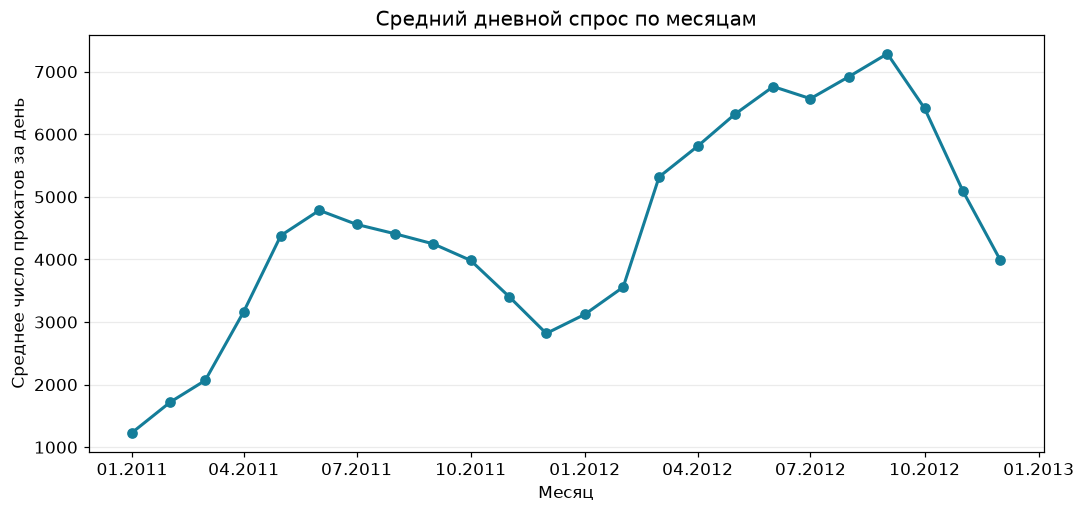

**Вывод.** Средний дневной спрос 2012 года выше 2011 года на 64.43%. Максимальное месячное среднее приходится на 09.2012: 7285.8 прокатов/день. Видны сезонные колебания; двух годовых циклов недостаточно для устойчивого долгосрочного прогноза.

In [ ]:
monthly = clean_df.set_index("dteday").sort_index().resample("MS").agg(
    days=("cnt", "size"), total_rentals=("cnt", "sum"), mean_daily_rentals=("cnt", "mean"),
)
yearly = clean_df.groupby(clean_df.dteday.dt.year).agg(
    days=("cnt", "size"), total_rentals=("cnt", "sum"), mean_daily_rentals=("cnt", "mean"),
)
assert monthly.days.sum() == len(clean_df) and monthly.total_rentals.sum() == clean_df.cnt.sum()
display(monthly.round(2))
display(yearly.round(2))
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(monthly.index, monthly.mean_daily_rentals, marker="o", color="#147d99", linewidth=2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%Y"))
ax.set(xlabel="Месяц", ylabel="Среднее число прокатов за день", title="Средний дневной спрос по месяцам")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG / "04_monthly.png", dpi=150)
plt.show()
growth = (yearly.loc[2012, "mean_daily_rentals"] / yearly.loc[2011, "mean_daily_rentals"] - 1) * 100
peak = monthly.mean_daily_rentals.idxmax()
display(Markdown(f"**Вывод.** Средний дневной спрос 2012 года выше 2011 года на {growth:.2f}%. "
                 f"Максимальное месячное среднее приходится на {peak:%m.%Y}: "
                 f"{monthly.loc[peak, 'mean_daily_rentals']:.1f} прокатов/день. "
                 "Видны сезонные колебания; двух годовых циклов недостаточно для устойчивого долгосрочного прогноза."))

## 10. Экспорт, схема и проверка повторного чтения
Сохраняется одна таблица из 731 строки и 19 полей. CSV и JSON не сохраняют
полную схему Pandas. В этом окружении Parquet также восстанавливает числовые
категории как int64. Схема сохраняется в отдельном JSON и восстанавливается явно.
Времена чтения - медианы пяти повторов с прогретым кешем, зависящие от компьютера.

In [ ]:
clean_df.to_csv(OUT / "BikeSharing_clean.csv", index=False, encoding="utf-8", date_format="%Y-%m-%d")
clean_df.to_json(OUT / "BikeSharing_clean.json", orient="records", lines=True, force_ascii=False,
                 date_format="iso", double_precision=15)
clean_df.to_parquet(OUT / "BikeSharing_clean.parquet", index=False, engine="pyarrow", compression="snappy")
schema = {}
for col, dtype in clean_df.dtypes.items():
    schema[col] = {"dtype": str(dtype)}
    if isinstance(dtype, pd.CategoricalDtype):
        schema[col].update(categories=dtype.categories.tolist(), ordered=dtype.ordered)
(OUT / "BikeSharing_schema.json").write_text(json.dumps(schema, indent=2), encoding="utf-8")
saved_schema = json.loads((OUT / "BikeSharing_schema.json").read_text(encoding="utf-8"))
restore_dtypes = {
    col: (pd.CategoricalDtype(meta["categories"], ordered=meta["ordered"])
          if meta["dtype"] == "category" else meta["dtype"])
    for col, meta in saved_schema.items()
}
readers = {
    "csv": lambda: pd.read_csv(OUT / "BikeSharing_clean.csv", encoding="utf-8", parse_dates=["dteday"]),
    "json": lambda: pd.read_json(OUT / "BikeSharing_clean.json", orient="records", lines=True, convert_dates=["dteday"]),
    "parquet": lambda: pd.read_parquet(OUT / "BikeSharing_clean.parquet", engine="pyarrow"),
}
back = {fmt: reader() for fmt, reader in readers.items()}
file_stats = []
for fmt, reader in readers.items():
    restored = back[fmt]
    assert restored.shape == clean_df.shape
    if fmt == "parquet":
        pd.testing.assert_frame_equal(clean_df, restored.astype(restore_dtypes), check_exact=True)
    else:
        pd.testing.assert_frame_equal(clean_df, restored.astype(restore_dtypes),
                                      check_exact=False, rtol=1e-10, atol=1e-9)
    durations = []
    for _ in range(5):
        start = perf_counter()
        reader()
        durations.append((perf_counter() - start) * 1000)
    path = OUT / f"BikeSharing_clean.{fmt}"
    file_stats.append({"Формат": fmt, "Байт": path.stat().st_size,
                       "KiB": path.stat().st_size / 1024, "Чтение, мс": np.median(durations),
                       "Строк": len(restored), "Столбцов": len(restored.columns), "Значения совпали": True,
                       "Типы совпали без приведения": restored.dtypes.equals(clean_df.dtypes)})
file_stats = pd.DataFrame(file_stats).set_index("Формат")
display(file_stats)
display(pd.DataFrame({"До записи": clean_df.dtypes.astype(str),
                      **{fmt: data.dtypes.astype(str) for fmt, data in back.items()}}))
partial = pd.read_parquet(OUT / "BikeSharing_clean.parquet", columns=["dteday", "cnt"])
pd.testing.assert_frame_equal(partial, clean_df[["dteday", "cnt"]])
display(Markdown("**Вывод.** Во всех форматах восстановлены все строки и значения (для текстовых "
                 "чисел допуск 1e-9 плюс относительный 1e-10). Parquet сохранил точные числовые значения, "
                 "дату, компактные счётчики и bool, но числовые категории вернулись как int64. "
                 "Полная схема успешно восстановлена из `BikeSharing_schema.json` и проверена. "
                 "Проверено выборочное чтение даты и числа прокатов из Parquet."))
print("Размер схемы, байт:", (OUT / "BikeSharing_schema.json").stat().st_size)

,Байт,KiB,"Чтение, мс",Строк,Столбцов,Значения совпали,Типы совпали без приведения
Формат,,,,,,,
csv,88382,86.311,3.939,731,19,True,False
json,251341,245.450,11.203,731,19,True,False
parquet,64052,62.551,3.886,731,19,True,False


,До записи,csv,json,parquet
instant,uint16,int64,int64,uint16
dteday,datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns]
season,category,int64,int64,int64
yr,category,int64,int64,int64
mnth,category,int64,int64,int64
holiday,bool,bool,bool,bool
weekday,category,int64,int64,int64
workingday,bool,bool,bool,bool
weathersit,category,int64,int64,int64
temp,float64,float64,float64,float64


**Вывод.** Во всех форматах восстановлены все строки и значения (для текстовых чисел допуск 1e-9 плюс относительный 1e-10). Parquet сохранил точные числовые значения, дату, компактные счётчики и bool, но числовые категории вернулись как int64. Полная схема успешно восстановлена из `BikeSharing_schema.json` и проверена. Проверено выборочное чтение даты и числа прокатов из Parquet.

Размер схемы, байт: 1426


## 11. Итоговые выводы и ограничения

In [ ]:
summary = {
    "source_rows": len(df), "source_columns": df.shape[1], "clean_rows": len(clean_df),
    "clean_columns": clean_df.shape[1], "missing": int(df.isna().sum().sum()), "duplicates": duplicates,
    "first_date": dates.min().strftime("%Y-%m-%d"), "last_date": dates.max().strftime("%Y-%m-%d"),
    "memory_before_bytes": before, "memory_after_bytes": after, "memory_reduction_pct": memory_reduction,
    "filter_rows": len(subset), "zero_humidity_rows": len(zero_humidity),
    "temperature_demand_correlation": float(corr.loc["temp", "cnt"]),
    "mean_daily_growth_pct_2012": growth, "peak_month": peak.strftime("%Y-%m"),
    "roundtrip_all_formats": True,
    "parquet_requires_category_restore": not back["parquet"].dtypes.equals(clean_df.dtypes),
}
(OUT / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
weather_stats.to_csv(OUT / "weather_stats.csv", encoding="utf-8")
day_stats.to_csv(OUT / "workingday_stats.csv", encoding="utf-8")
monthly.to_csv(OUT / "monthly_stats.csv", encoding="utf-8")
yearly.to_csv(OUT / "yearly_stats.csv", encoding="utf-8")
outliers.to_csv(OUT / "iqr_stats.csv", encoding="utf-8")
file_stats.to_csv(OUT / "format_comparison.csv", encoding="utf-8")
display(Markdown(f"""
1. Набор содержит {len(df)} последовательных дней с {dates.min():%d.%m.%Y} по {dates.max():%d.%m.%Y}, без пропусков и полных дублей.
2. Оптимизация 16 исходных столбцов снизила память на {memory_reduction:.1f}%, сохранив значения.
3. Выявлено {len(zero_humidity)} дней с нулевой влажностью. Добавлен индикатор для дальнейшей проверки; строки не удалялись.
4. Средний дневной спрос по всему набору {clean_df.cnt.mean():.1f}, медиана {clean_df.cnt.median():.0f}; разброс от {clean_df.cnt.min()} до {clean_df.cnt.max()}.
5. Корреляция нормированной температуры со спросом равна {corr.loc['temp', 'cnt']:.3f}; это не оценка причинного влияния.
6. Доля casual в суммарном спросе нерабочих дней {day_stats.loc[False, 'casual_share_pct']:.2f}%, рабочих дней {day_stats.loc[True, 'casual_share_pct']:.2f}%.
7. Средний дневной спрос в 2012 году вырос на {growth:.2f}% относительно 2011 года; пик месячного среднего - {peak:%m.%Y}.
8. Три формата экспорта прошли проверку содержимого. Числовые категории Parquet потребовали явного восстановления из сохранённой схемы; точность значений подтверждена.

**Ограничения анализа.**

- Одна система и два исторических года не представляют современные показатели других городов. Суточные агрегаты скрывают часы пик.
- Наблюдательные связи погоды и спроса смешиваются с календарём, развитием системы и другими факторами. Причинность не установлена.
- Метаданные температуры и сезонов противоречивы, поэтому сохранены нормированные значения и коды без спорной расшифровки.
- Истинный смысл нулевой влажности не подтверждён. Автоматическая замена на среднее могла бы скрыть проблему источника.
"""))


1. Набор содержит 731 последовательных дней с 01.01.2011 по 31.12.2012, без пропусков и полных дублей.
2. Оптимизация 16 исходных столбцов снизила память на 69.6%, сохранив значения.
3. Выявлено 1 дней с нулевой влажностью. Добавлен индикатор для дальнейшей проверки; строки не удалялись.
4. Средний дневной спрос по всему набору 4504.3, медиана 4548; разброс от 22 до 8714.
5. Корреляция нормированной температуры со спросом равна 0.627; это не оценка причинного влияния.
6. Доля casual в суммарном спросе нерабочих дней 31.66%, рабочих дней 13.23%.
7. Средний дневной спрос в 2012 году вырос на 64.43% относительно 2011 года; пик месячного среднего - 09.2012.
8. Три формата экспорта прошли проверку содержимого. Числовые категории Parquet потребовали явного восстановления из сохранённой схемы; точность значений подтверждена.

**Ограничения анализа.**

- Одна система и два исторических года не представляют современные показатели других городов. Суточные агрегаты скрывают часы пик.
- Наблюдательные связи погоды и спроса смешиваются с календарём, развитием системы и другими факторами. Причинность не установлена.
- Метаданные температуры и сезонов противоречивы, поэтому сохранены нормированные значения и коды без спорной расшифровки.
- Истинный смысл нулевой влажности не подтверждён. Автоматическая замена на среднее могла бы скрыть проблему источника.
